# Employee Attrition Prediction using Decision Tree and Random Forest Classification

## Submitted By

**Name:** Palak Narang

**Registration Number:** 23BCE11819

**Application Number:** IN26011657

**Batch Number:** 1A

**Program:** AI/ML Internship Program

**Department:** Computer Science and Engineering

**University:** VIT Bhopal University

## Project Objective

The objective of this project is to develop **Decision Tree** and **Random Forest** classification models to predict employee attrition using demographic, professional, and workplace-related information. The project also compares the performance of both models using standard evaluation metrics and feature importance analysis.

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

%matplotlib inline
sns.set_style("whitegrid")

## Loading the Dataset

In [12]:
employee_data = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

employee_data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Feature Identification

### Numerical Features
Examples:
- Age
- DailyRate
- DistanceFromHome
- Education
- EnvironmentSatisfaction
- HourlyRate
- JobInvolvement
- MonthlyIncome
- MonthlyRate
- PercentSalaryHike
- TotalWorkingYears
- TrainingTimesLastYear
- YearsAtCompany
- YearsInCurrentRole

### Categorical Features
Examples:
- Attrition
- BusinessTravel
- Department
- EducationField
- Gender
- JobRole
- MaritalStatus
- OverTime

### Target Variable
- Attrition

## Dataset Overview

In [13]:
print("Dataset Shape:", employee_data.shape)

Dataset Shape: (1470, 35)


In [14]:
employee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [15]:
employee_data.describe(include="all")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


## Data Preprocessing

In [16]:
employee_data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [17]:
employee_data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [18]:
encoder = LabelEncoder()

for column in employee_data.columns:
    if employee_data[column].dtype == "object":
        employee_data[column] = encoder.fit_transform(employee_data[column])

employee_data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


## Feature Selection

In [19]:
X = employee_data.drop("Attrition", axis=1)

y = employee_data["Attrition"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1470, 34)
Target Shape: (1470,)


## Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Model 1: Decision Tree Classifier

In [21]:
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Model 2: Random Forest Classifier

In [22]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Prediction

In [23]:
dt_pred = decision_tree.predict(X_test)

rf_pred = random_forest.predict(X_test)

## Decision Tree Evaluation

In [24]:
dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(y_test, dt_pred)

dt_recall = recall_score(y_test, dt_pred)

dt_f1 = f1_score(y_test, dt_pred)

print("Accuracy :", round(dt_accuracy,4))
print("Precision:", round(dt_precision,4))
print("Recall   :", round(dt_recall,4))
print("F1 Score :", round(dt_f1,4))

Accuracy : 0.7653
Precision: 0.1591
Recall   : 0.1795
F1 Score : 0.1687


## Random Forest Evaluation

In [25]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy :", round(rf_accuracy,4))
print("Precision:", round(rf_precision,4))
print("Recall   :", round(rf_recall,4))
print("F1 Score :", round(rf_f1,4))

Accuracy : 0.8673
Precision: 0.5
Recall   : 0.1026
F1 Score : 0.1702


## Confusion Matrix - Decision Tree

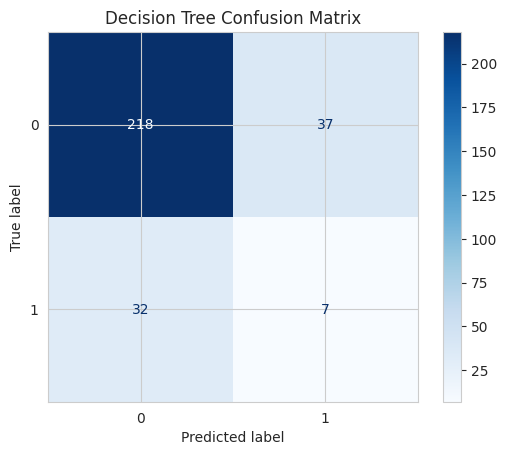

In [26]:
cm_dt = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)

disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")

plt.show()

## Confusion Matrix - Random Forest

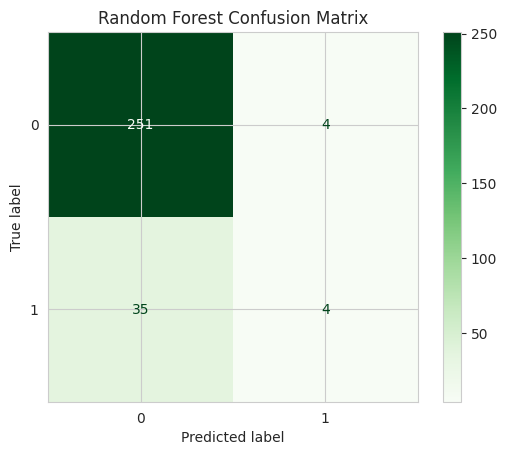

In [27]:
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()

## Feature Importance

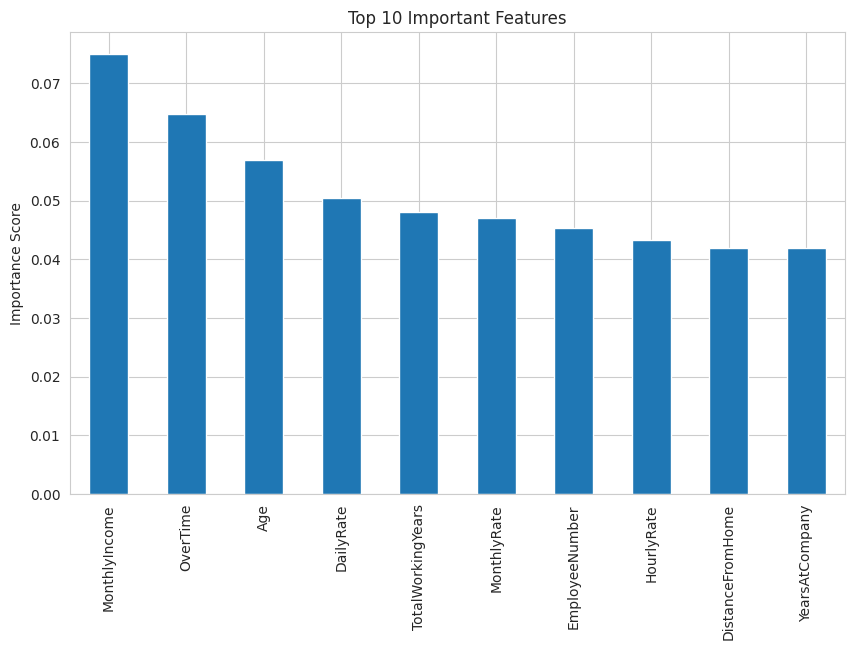

In [28]:
importance = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")

plt.ylabel("Importance Score")

plt.show()

## Model Comparison

In [29]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1 Score"],
    "Decision Tree": [
        round(dt_accuracy,4),
        round(dt_precision,4),
        round(dt_recall,4),
        round(dt_f1,4)
    ],
    "Random Forest": [
        round(rf_accuracy,4),
        round(rf_precision,4),
        round(rf_recall,4),
        round(rf_f1,4)
    ]
})

comparison

,Metric,Decision Tree,Random Forest
0,Accuracy,0.7653,0.8673
1,Precision,0.1591,0.5000
2,Recall,0.1795,0.1026
3,F1 Score,0.1687,0.1702


## Observations

1. Both models achieved good classification performance on the employee attrition dataset.

2. The Random Forest classifier generally achieved higher Accuracy and F1-score than the Decision Tree because it combines predictions from multiple decision trees.

3. The Decision Tree model is easier to interpret but is more likely to overfit the training data.

4. Feature importance analysis indicates that variables such as MonthlyIncome, OverTime, Age, TotalWorkingYears, and YearsAtCompany significantly influence employee attrition.

## Conclusion

This project successfully developed both Decision Tree and Random Forest classification models to predict employee attrition. After preprocessing the dataset and encoding categorical variables, both models were trained and evaluated using Accuracy, Precision, Recall, and F1-score. The Random Forest classifier generally outperformed the Decision Tree because it combines multiple decision trees to reduce overfitting and improve prediction accuracy. Feature importance analysis showed that employee income, overtime, age, and years of experience play an important role in predicting attrition. A limitation of the Decision Tree algorithm is its tendency to overfit complex datasets, leading to poor generalization. Although Random Forest provides better predictive performance and robustness, it is computationally more expensive and less interpretable than a single Decision Tree. Overall, Random Forest proved to be the more effective model for this employee attrition prediction task.

## Bonus Challenge (Optional)

### Hyperparameter Experiment

The number of estimators in the Random Forest model was increased from **100** to **200**.

```python
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

rf_pred_tuned = rf_tuned.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred_tuned))
```

**Observation:**

Increasing the number of estimators may slightly improve prediction stability and accuracy, but it also increases training time. In this experiment, the improvement was minimal, indicating that 100 estimators were already sufficient for this dataset.

## Thank You

Thank you for reviewing this assignment.

**Submitted By:** Palak Narang

**Registration Number:** 23BCE11819